 # Evolucao dos Casos de Dengue no Brasil (2015-2024)
**Alunos:** Ariene Viana e João Marcelo Lopes
## Projeto G2 — Linguagem de Programacao

---

**Alunos:** Ariene Viana e João Marcelo Lopes

**Periodo analisado:** 2015 a 2024

---

## 1. Introducao

A dengue e uma das doencas que mais preocupam o Brasil em termos de saude publica.
Transmitida pelo mosquito *Aedes aegypti*, ela afeta milhares de pessoas todos os anos,
especialmente nos periodos de verao, quando as chuvas criam condicoes ideais para a
reproducao do mosquito.

Neste projeto, vamos analisar os dados de dengue no Brasil entre 2015 e 2024,
buscando entender melhor como a doenca se comporta ao longo do tempo e do territorio.

**O que queremos descobrir:**
- Quais estados tem mais casos de dengue?
- Em quais meses do ano os casos aumentam mais?
- Os casos cresceram ao longo dos anos?
- Existe relacao entre chuva e aumento de casos?
- Quais municipios sao mais afetados?

In [1]:
!pip install plotly sqlalchemy --quiet

import warnings
warnings.filterwarnings('ignore')


import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


from sqlalchemy import create_engine, text


sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11})


CORES = {'Norte':'#3182ce','Nordeste':'#dd6b20',
         'Centro-Oeste':'#38a169','Sudeste':'#e53e3e','Sul':'#805ad5'}


MESES = ['Jan','Fev','Mar','Abr','Mai','Jun',
         'Jul','Ago','Set','Out','Nov','Dez']

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 2. Upload e Leitura do CSV

In [3]:
from google.colab import files

print('Clique em Escolher arquivos e selecione:')
print('   simulacao_dengue_brasil.csv')
print()

uploaded = files.upload()
nome_arquivo = list(uploaded.keys())[0]


df_raw = pd.read_csv(nome_arquivo)
print(f'Arquivo carregado: {nome_arquivo}')
print(f'{df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas')
df_raw.head()

Clique em Escolher arquivos e selecione:
   simulacao_dengue_brasil.csv



Saving simulacao_dengue_brasil.csv to simulacao_dengue_brasil.csv
Arquivo carregado: simulacao_dengue_brasil.csv
4,440 linhas x 14 colunas


,ano,mes,data,regiao,uf,municipio,populacao,chuva_mm,temperatura_media,casos_dengue,internacoes,obitos,incidencia_100k,nivel_alerta
0,2015,1,2015-01-01,Norte,AM,Manaus,2708209,141.6,26.6,998,43,2,36.85,Médio
1,2015,1,2015-01-01,Norte,PA,Belém,711775,161.5,26.4,229,12,0,32.17,Médio
2,2015,1,2015-01-01,Norte,PA,Santarém,2249561,128.9,26.1,776,35,2,34.50,Médio
3,2015,1,2015-01-01,Norte,RO,Porto Velho,2198291,180.8,28.5,915,51,3,41.62,Médio
4,2015,1,2015-01-01,Norte,TO,Palmas,2193271,151.1,24.7,760,37,0,34.65,Médio


## 3. Limpeza e Preparacao dos Dados

In [ ]:
print('=== INFORMACOES DO DATASET ===')
df_raw.info()
print('\n=== VALORES NULOS ===')
print(df_raw.isnull().sum())
print('\n=== ESTATISTICAS DESCRITIVAS ===')
display(df_raw.describe().round(2))

In [5]:
df = df_raw.copy()


df['data'] = pd.to_datetime(df['data'])


for c in ['ano','mes','populacao','casos_dengue','internacoes','obitos']:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0).astype(int)
for c in ['chuva_mm','temperatura_media','incidencia_100k']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df['regiao']       = df['regiao'].str.strip().str.title()
df['uf']           = df['uf'].str.strip().str.upper()
df['municipio']    = df['municipio'].str.strip().str.title()
df['nivel_alerta'] = df['nivel_alerta'].str.strip().str.title()


antes = len(df)
df = df.drop_duplicates()
print(f'Duplicatas removidas: {antes - len(df)}')
print(f'Dataset limpo: {df.shape[0]:,} linhas | Nulos restantes: {df.isnull().sum().sum()}')

Duplicatas removidas: 0
Dataset limpo: 4,440 linhas | Nulos restantes: 0


## 4. Engenharia de Atributos (Novas Colunas)

In [6]:
df['nome_mes'] = df['mes'].apply(lambda x: MESES[x-1])


def estacao(m):
    if m in [12,1,2]:  return 'Verao'
    if m in [3,4,5]:   return 'Outono'
    if m in [6,7,8]:   return 'Inverno'
    return 'Primavera'
df['estacao'] = df['mes'].apply(estacao)


df['taxa_letalidade'] = np.where(df['casos_dengue']>0,
    df['obitos']/df['casos_dengue']*100, 0).round(4)


df['taxa_internacao'] = np.where(df['casos_dengue']>0,
    df['internacoes']/df['casos_dengue']*100, 0).round(2)

print('Novas colunas criadas com sucesso!')
df[['nome_mes','estacao','taxa_letalidade','taxa_internacao']].head(3)

Novas colunas criadas com sucesso!


,nome_mes,estacao,taxa_letalidade,taxa_internacao
0,Jan,Verao,0.2004,4.31
1,Jan,Verao,0.0000,5.24
2,Jan,Verao,0.2577,4.51


## 5. KPIs — Indicadores Principais

In [7]:
total_casos  = df['casos_dengue'].sum()
total_ob     = df['obitos'].sum()
total_int    = df['internacoes'].sum()
media_men    = df.groupby(['ano','mes'])['casos_dengue'].sum().mean()
inc_media    = df['incidencia_100k'].mean()
uf_top       = df.groupby('uf')['casos_dengue'].sum().idxmax()
uf_top_v     = df.groupby('uf')['casos_dengue'].sum().max()
mun_top      = df.groupby('municipio')['incidencia_100k'].mean().idxmax()
mun_inc      = df.groupby('municipio')['incidencia_100k'].mean().max()
ano_pico     = df.groupby('ano')['casos_dengue'].sum().idxmax()
ano_pico_v   = df.groupby('ano')['casos_dengue'].sum().max()

print('=' * 55)
print('      PAINEL DE KPIs - DENGUE NO BRASIL')
print('=' * 55)
print(f'  Total de Casos          : {total_casos:>12,.0f}')
print(f'  Total de Obitos         : {total_ob:>12,.0f}')
print(f'  Total de Internacoes    : {total_int:>12,.0f}')
print(f'  Media Mensal de Casos   : {media_men:>12,.0f}')
print(f'  Incidencia Media /100k  : {inc_media:>12.1f}')
print(f'  Estado Mais Afetado     : {uf_top} ({uf_top_v:,.0f} casos)')
print(f'  Municipio Critico       : {mun_top} ({mun_inc:.1f}/100k)')
print(f'  Ano de Pico             : {ano_pico} ({ano_pico_v:,.0f} casos)')
print('=' * 55)

      PAINEL DE KPIs - DENGUE NO BRASIL
  Total de Casos          :    3,560,562
  Total de Obitos         :        5,314
  Total de Internacoes    :      178,670
  Media Mensal de Casos   :       29,671
  Incidencia Media /100k  :         30.9
  Estado Mais Afetado     : RJ (391,014 casos)
  Municipio Critico       : Campinas (32.8/100k)
  Ano de Pico             : 2018 (374,478 casos)


## 6. Graficos

### 6.1 Evolucao Temporal dos Casos

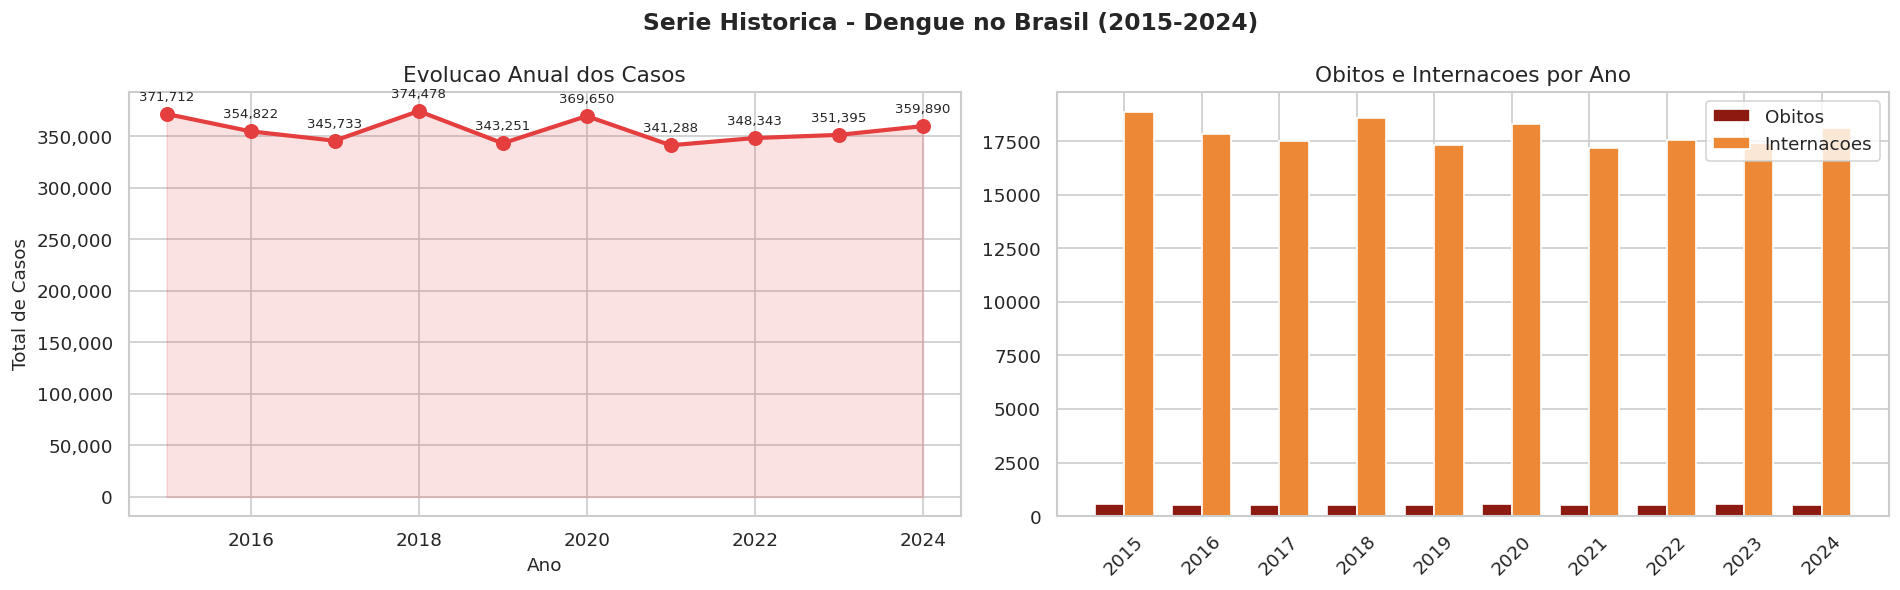

In [8]:
por_ano = df.groupby('ano').agg(
    casos=('casos_dengue','sum'),
    obitos=('obitos','sum'),
    internacoes=('internacoes','sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))


axes[0].plot(por_ano['ano'], por_ano['casos'],
             marker='o', lw=2.5, color='#e53e3e', ms=8)
axes[0].fill_between(por_ano['ano'], por_ano['casos'],
                      alpha=0.15, color='#e53e3e')
axes[0].set_title('Evolucao Anual dos Casos')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Total de Casos')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for x,y in zip(por_ano['ano'], por_ano['casos']):
    axes[0].annotate(f'{y:,.0f}', (x,y),
                     xytext=(0,8), textcoords='offset points',
                     ha='center', fontsize=8)


x = np.arange(len(por_ano)); w = 0.38
axes[1].bar(x-w/2, por_ano['obitos'],     w,
            label='Obitos',      color='#8c1a11')
axes[1].bar(x+w/2, por_ano['internacoes'],w,
            label='Internacoes', color='#ed8936')
axes[1].set_title('Obitos e Internacoes por Ano')
axes[1].set_xticks(x)
axes[1].set_xticklabels(por_ano['ano'], rotation=45)
axes[1].legend()

plt.suptitle('Serie Historica - Dengue no Brasil (2015-2024)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Observando o grafico conseguimos identificar os anos com maior
numero de casos. Picos epidemicos costumam ocorrer quando um novo sorotipo
do virus se espalha pela populacao ou quando as condicoes climaticas sao
especialmente favoraveis para o mosquito. Vale notar se ha uma tendencia
de crescimento ou reducao ao longo da serie historica.

### 6.2 Comparacao entre Regioes

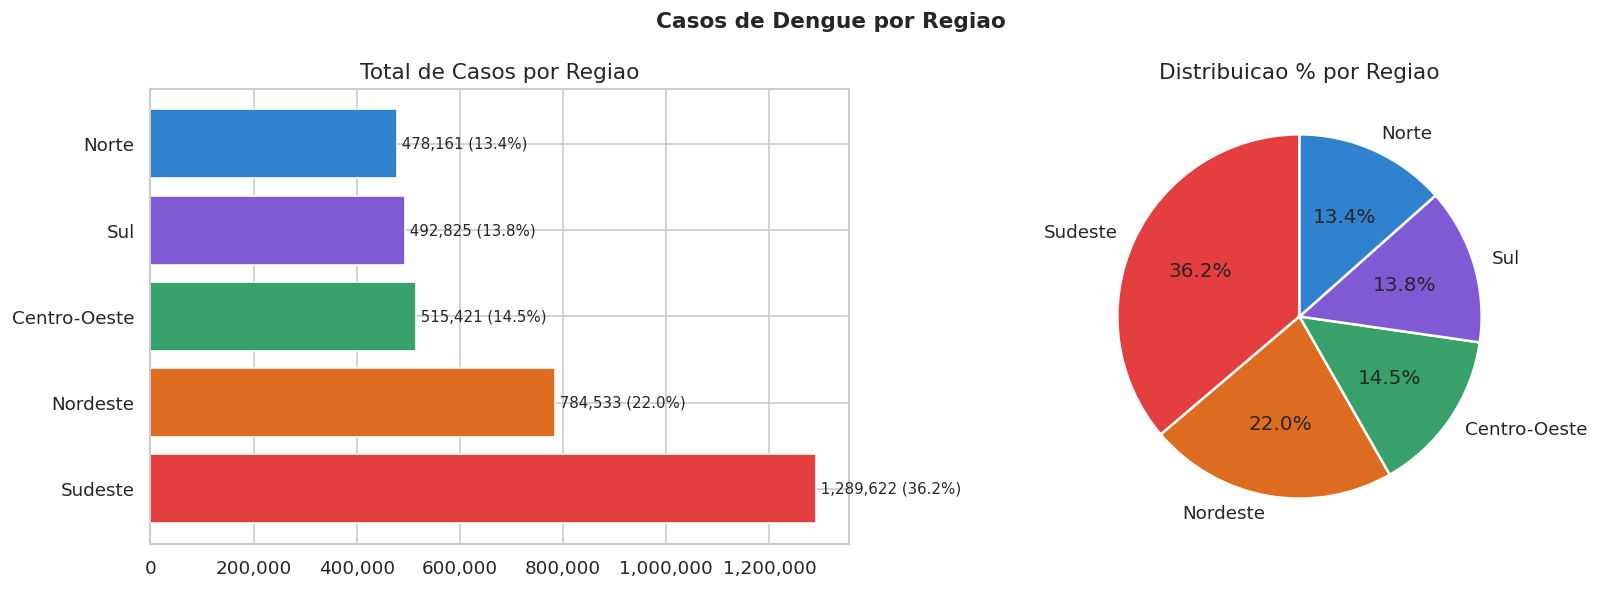

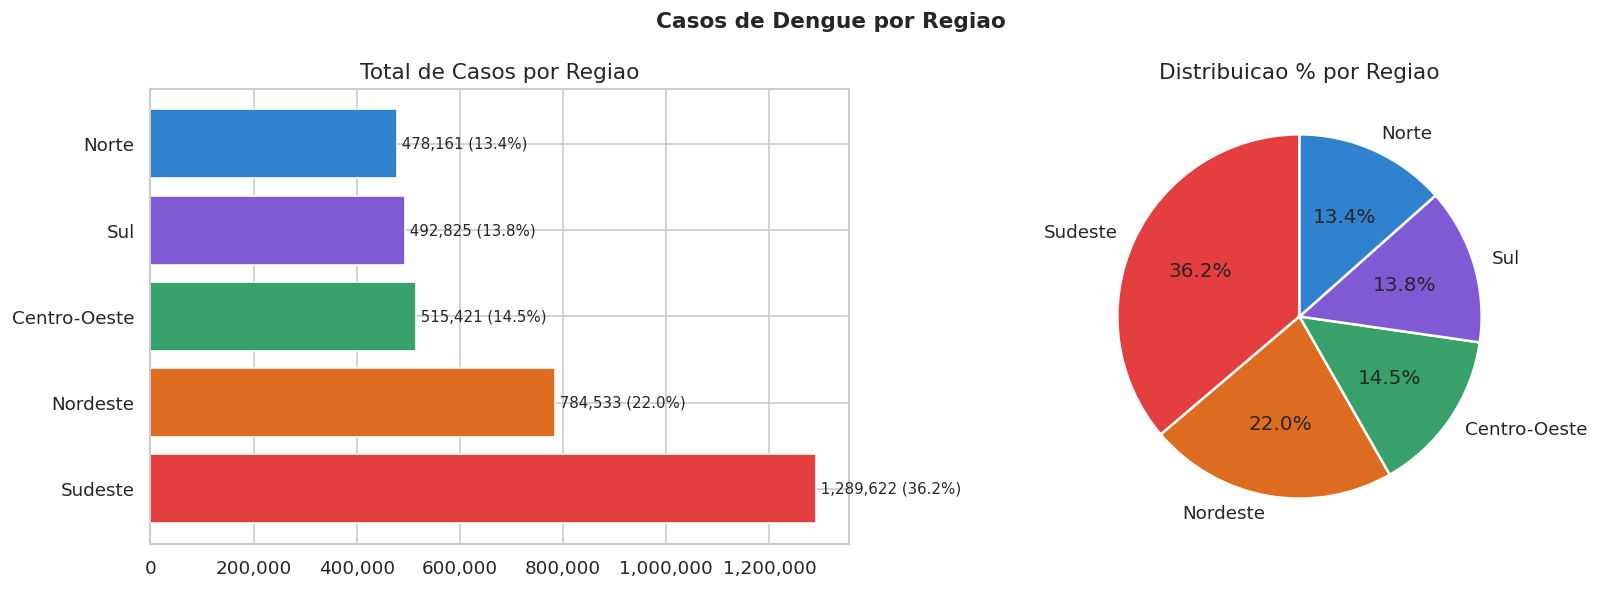

In [10]:
por_reg = df.groupby('regiao')['casos_dengue'].sum()\
            .sort_values(ascending=False).reset_index()
por_reg['pct'] = (por_reg['casos_dengue']/por_reg['casos_dengue'].sum()*100).round(1)
cores_lista = [CORES.get(r,'#aaa') for r in por_reg['regiao']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].barh(por_reg['regiao'], por_reg['casos_dengue'], color=cores_lista)
axes[0].set_title('Total de Casos por Regiao')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for i,(v,p) in enumerate(zip(por_reg['casos_dengue'], por_reg['pct'])):
    axes[0].text(v+100, i, f' {v:,.0f} ({p}%)', va='center', fontsize=9)


axes[1].pie(por_reg['casos_dengue'], labels=por_reg['regiao'],
            autopct='%1.1f%%', colors=cores_lista, startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Distribuicao % por Regiao')

plt.suptitle('Casos de Dengue por Regiao', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

A distribuicao regional mostra que a dengue nao afeta o Brasil
de forma uniforme. Regioes com clima mais quente e umido tendem a concentrar
mais casos, pois o *Aedes aegypti* se desenvolve melhor nessas condicoes.
O grafico de pizza deixa claro o peso relativo de cada regiao no total nacional.

In [11]:
por_reg_ano = df.groupby(['ano','regiao'])['casos_dengue'].sum().reset_index()
fig = px.line(por_reg_ano, x='ano', y='casos_dengue', color='regiao',
              markers=True, color_discrete_map=CORES,
              title='Evolucao por Regiao (2015-2024)',
              labels={'casos_dengue':'Casos','ano':'Ano','regiao':'Regiao'})
fig.update_layout(hovermode='x unified')
fig.show()

 O grafico interativo permite comparar o ritmo de crescimento
de cada regiao. E possivel identificar se os anos de pico foram sincronizados
em todo o pais ou se afetaram regioes diferentes em momentos distintos.
Passe o mouse sobre os pontos para ver os valores exatos de cada ano.

### 6.3 Comparacao entre Estados (UF)

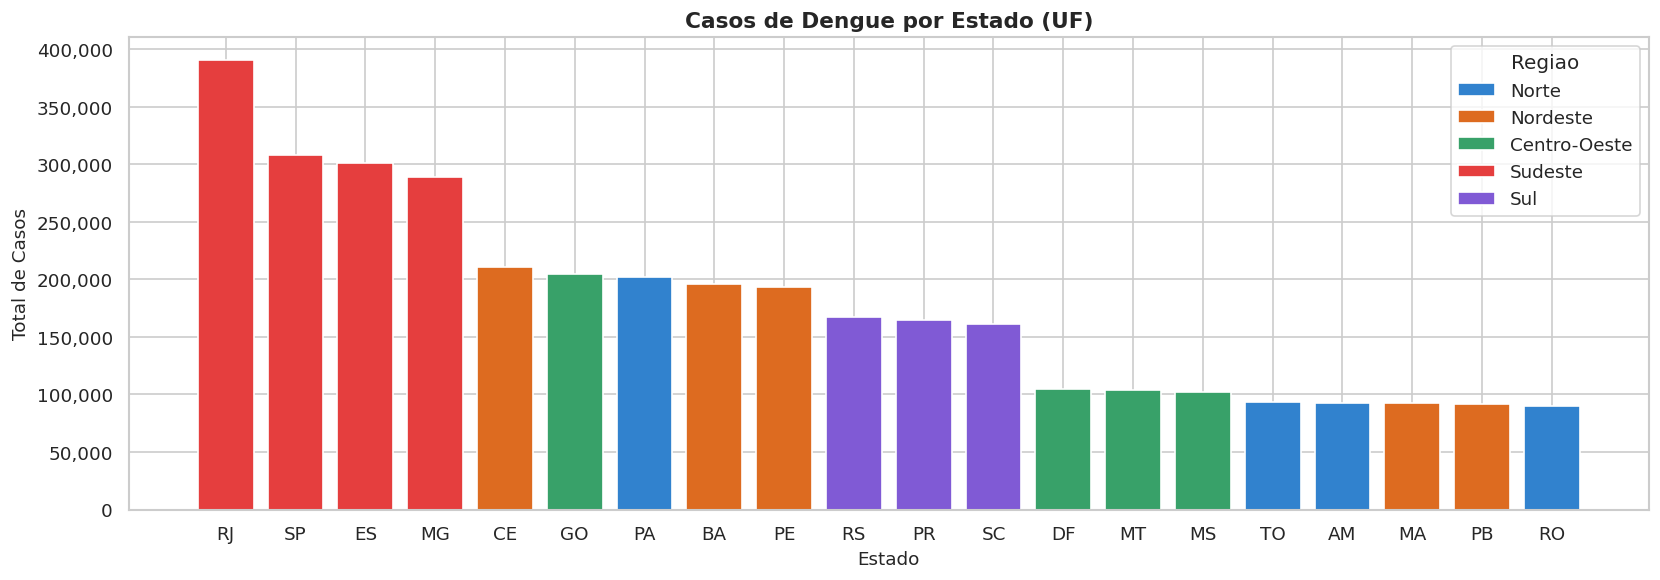

In [12]:
por_uf = df.groupby(['uf','regiao'])['casos_dengue'].sum()\
           .reset_index().sort_values('casos_dengue', ascending=False)
cores_uf = [CORES.get(r,'#aaa') for r in por_uf['regiao']]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(por_uf['uf'], por_uf['casos_dengue'], color=cores_uf, edgecolor='white')
ax.set_title('Casos de Dengue por Estado (UF)', fontsize=13, fontweight='bold')
ax.set_xlabel('Estado')
ax.set_ylabel('Total de Casos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=v,label=k) for k,v in CORES.items()],
          title='Regiao', loc='upper right')
plt.tight_layout()
plt.show()

O ranking de estados mostra quais unidades federativas concentram
a maior carga da dengue no Brasil. Estados com grandes centros urbanos e clima
favoravel tendem a liderar o ranking. E importante comparar tanto o volume
absoluto de casos quanto a incidencia por habitante para uma analise mais justa.

### 6.4 Ranking de Municipios

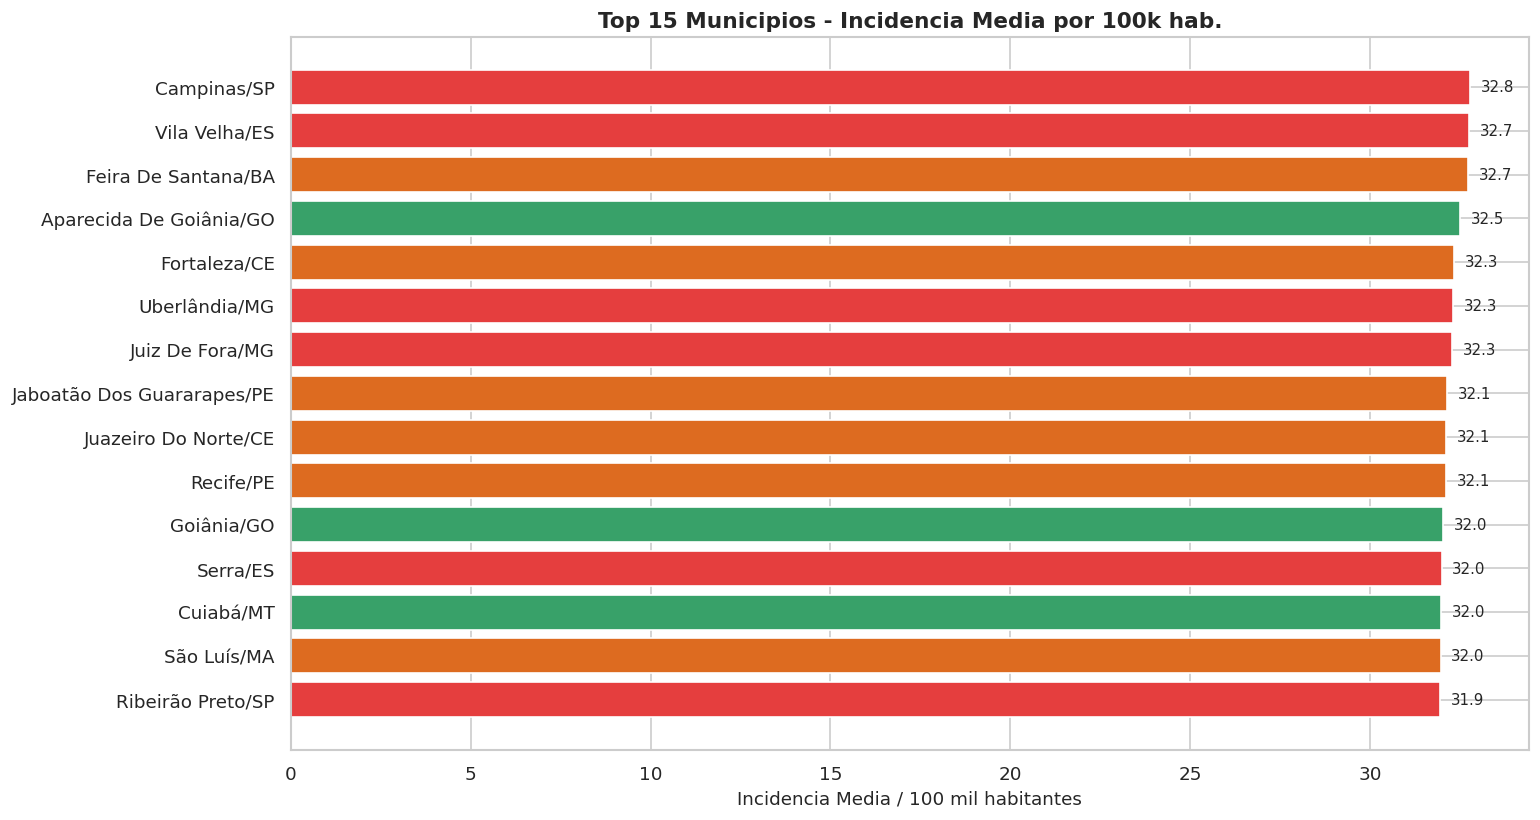


Tabela - Top 15 Municipios


,municipio,uf,regiao,casos,incidencia,obitos
0,Campinas,SP,Sudeste,"97,155",32.8,148
1,Vila Velha,ES,Sudeste,"107,215",32.7,169
2,Feira De Santana,BA,Nordeste,"100,245",32.7,144
3,Aparecida De Goiânia,GO,Centro-Oeste,"103,980",32.5,178
4,Fortaleza,CE,Nordeste,"105,937",32.3,147
5,Uberlândia,MG,Sudeste,"94,687",32.3,129
6,Juiz De Fora,MG,Sudeste,"99,068",32.3,155
7,Jaboatão Dos Guararapes,PE,Nordeste,"92,571",32.1,150
8,Juazeiro Do Norte,CE,Nordeste,"104,715",32.1,175
9,Recife,PE,Nordeste,"100,863",32.1,160


In [13]:
rank = df.groupby(['municipio','uf','regiao'])\
         .agg(casos=('casos_dengue','sum'),
              incidencia=('incidencia_100k','mean'),
              obitos=('obitos','sum'))\
         .reset_index()\
         .sort_values('incidencia', ascending=False)\
         .head(15)

cores_m = [CORES.get(r,'#aaa') for r in rank['regiao']]
labels  = rank['municipio'] + '/' + rank['uf']

fig, ax = plt.subplots(figsize=(13, 7))
ax.barh(labels[::-1], rank['incidencia'][::-1], color=cores_m[::-1])
ax.set_title('Top 15 Municipios - Incidencia Media por 100k hab.',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Incidencia Media / 100 mil habitantes')
for i,v in enumerate(rank['incidencia'][::-1]):
    ax.text(v+0.3, i, f'{v:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nTabela - Top 15 Municipios')
display(rank.reset_index(drop=True).style.format(
    {'casos':'{:,.0f}','incidencia':'{:.1f}','obitos':'{:,.0f}'}
).background_gradient(subset=['incidencia'], cmap='OrRd'))

O ranking de municipios pela incidencia media revela os locais
com maior concentracao proporcional de casos. Esses municipios merecem
atencao prioritaria das autoridades sanitarias, pois indicam areas onde
o controle do mosquito e mais urgente. A tabela abaixo do grafico traz
os numeros detalhados de cada municipio.

### 6.5 Heatmap de Sazonalidade

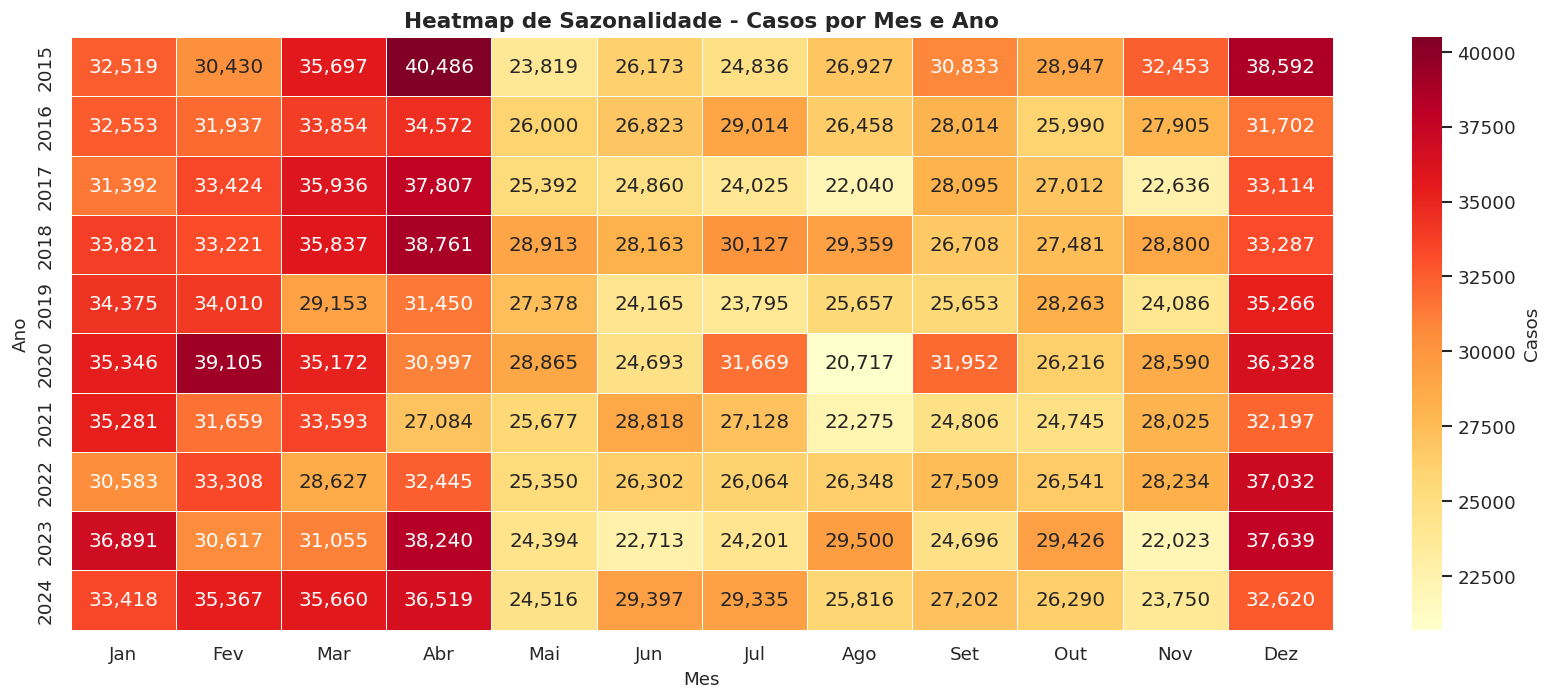

In [14]:
pivot = df.groupby(['ano','mes'])['casos_dengue'].sum()\
          .unstack('mes').fillna(0)
pivot.columns = [MESES[c-1] for c in pivot.columns]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label':'Casos'}, ax=ax)
ax.set_title('Heatmap de Sazonalidade - Casos por Mes e Ano',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Ano')
plt.tight_layout()
plt.show()

O heatmap deixa claro o padrao sazonal da dengue. As celulas
mais escuras se concentram nos primeiros meses do ano (janeiro a abril),
que correspondem ao verao no hemisferio Sul. Esse e o periodo de maior
calor e chuvas, favorecendo a proliferacao do mosquito. Esse padrao
se repete praticamente em todos os anos analisados.

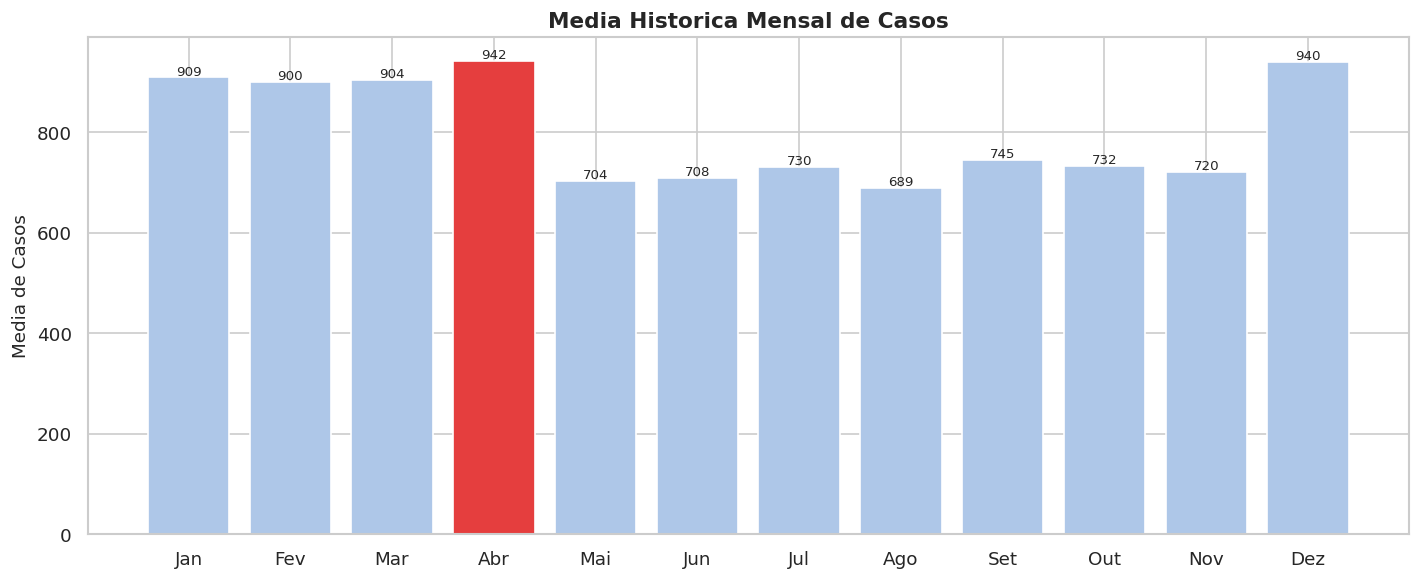

Mes historicamente mais critico: Abr


In [15]:
sazon = df.groupby('mes')['casos_dengue'].mean().reset_index()
sazon['nome_mes'] = sazon['mes'].apply(lambda x: MESES[x-1])
mes_pico = sazon.loc[sazon['casos_dengue'].idxmax(), 'nome_mes']

cores_b = ['#e53e3e' if v==sazon['casos_dengue'].max()
           else '#aec7e8' for v in sazon['casos_dengue']]
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(sazon['nome_mes'], sazon['casos_dengue'],
       color=cores_b, edgecolor='white')
ax.set_title('Media Historica Mensal de Casos', fontsize=13, fontweight='bold')
ax.set_ylabel('Media de Casos')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for i,v in enumerate(sazon['casos_dengue']):
    ax.text(i, v+5, f'{v:,.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print(f'Mes historicamente mais critico: {mes_pico}')

O grafico de media mensal confirma o padrao identificado no heatmap.
O mes em vermelho e o mais critico historicamente. Esse tipo de informacao
e essencial para o planejamento de acoes preventivas — os agentes de saude
devem intensificar o trabalho de campo nos meses anteriores ao pico,
preferencialmente entre outubro e dezembro.

### 6.6 Relacao entre Chuva e Casos de Dengue

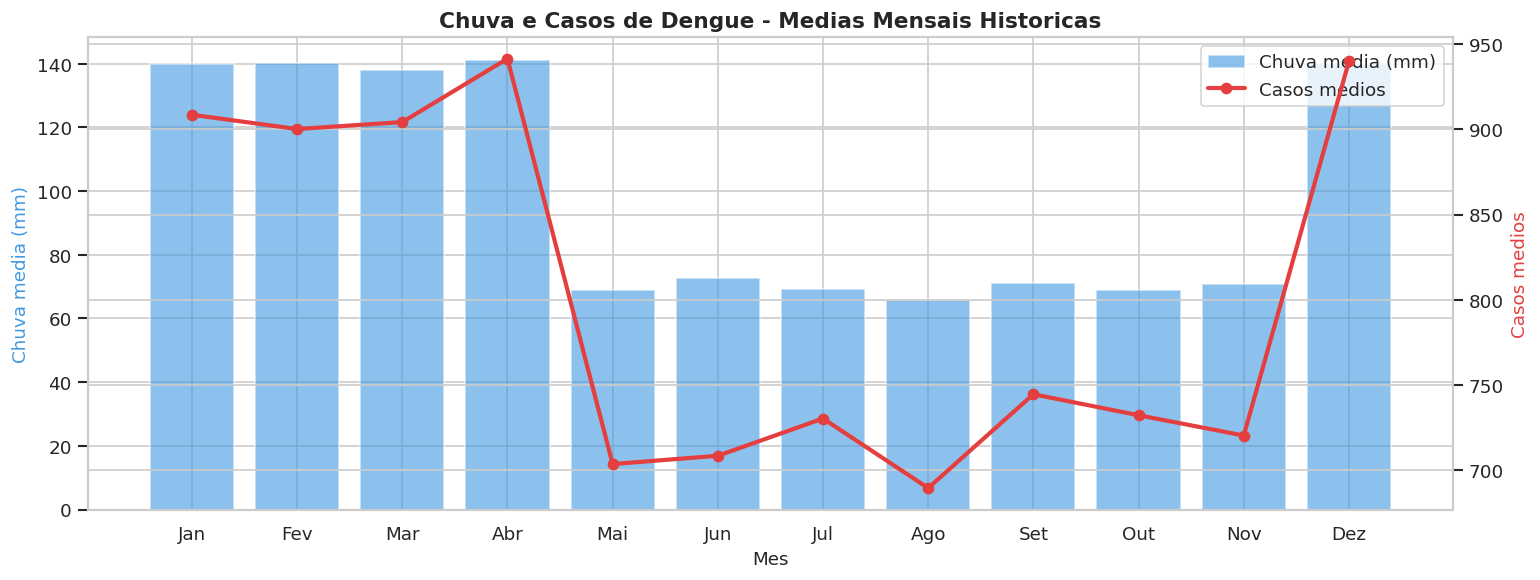

Correlacao de Pearson (chuva x casos): r = 0.2924 -> FRACA


In [16]:
med = df.groupby('mes').agg(
    chuva=('chuva_mm','mean'),
    casos=('casos_dengue','mean')).reset_index()
med['nome_mes'] = med['mes'].apply(lambda x: MESES[x-1])

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(med['nome_mes'], med['chuva'],
        color='#4299e1', alpha=0.6, label='Chuva media (mm)')
ax2.plot(med['nome_mes'], med['casos'],
         color='#e53e3e', marker='o', lw=2.5, label='Casos medios')

ax1.set_title('Chuva e Casos de Dengue - Medias Mensais Historicas',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Mes')
ax1.set_ylabel('Chuva media (mm)', color='#4299e1')
ax2.set_ylabel('Casos medios', color='#e53e3e')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()


r = df[['chuva_mm','casos_dengue']].corr().iloc[0,1]
forca = 'FORTE' if abs(r)>.6 else 'MODERADA' if abs(r)>.3 else 'FRACA'
print(f'Correlacao de Pearson (chuva x casos): r = {r:.4f} -> {forca}')

O grafico com eixo duplo permite observar visualmente se os
picos de chuva coincidem com os picos de casos. Note que existe uma
defasagem de aproximadamente 2 a 4 semanas entre o aumento das chuvas
e o aumento dos casos — esse e o tempo necessario para o ciclo de vida
do mosquito se completar. O coeficiente de Pearson confirma numericamente
a forca dessa relacao.

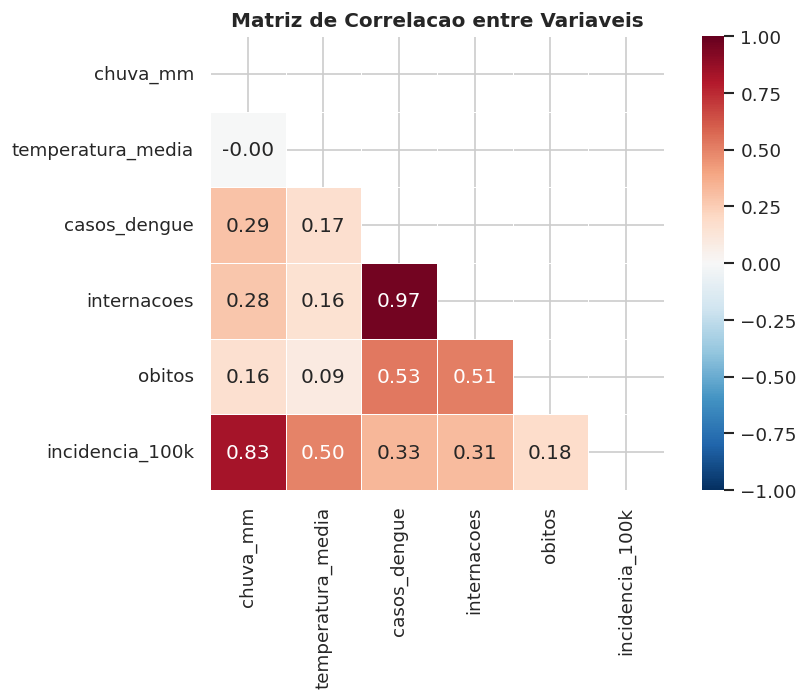

In [17]:
cols = ['chuva_mm','temperatura_media','casos_dengue',
        'internacoes','obitos','incidencia_100k']
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(df[cols].corr(), dtype=bool))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', vmin=-1, vmax=1,
            mask=mask, linewidths=0.5, square=True, ax=ax)
ax.set_title('Matriz de Correlacao entre Variaveis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

A matriz de correlacao revela quais variaveis estao mais
associadas entre si. Espera-se encontrar correlacao positiva entre casos,
internacoes e obitos (variaveis epidemiologicas que tendem a crescer juntas),
e tambem alguma correlacao entre chuva e casos. Variaveis com correlacao
proxima de zero nao tem relacao linear significativa.

### 6.7 Tabela Dinamica — Casos por UF e Ano

In [18]:
tabela = pd.pivot_table(df, index='uf', columns='ano',
                         values='casos_dengue', aggfunc='sum',
                         fill_value=0, margins=True, margins_name='TOTAL')
tabela.columns = [str(c) for c in tabela.columns]

print('Casos de Dengue por Estado e Ano')
display(tabela.style
        .format('{:,.0f}')
        .background_gradient(cmap='Reds',
                              subset=pd.IndexSlice[:, tabela.columns[:-1]])
        .set_caption('Tabela Dinamica - Casos por UF x Ano'))

Casos de Dengue por Estado e Ano


,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,TOTAL
uf,,,,,,,,,,,
AM,"11,969","11,793","7,975","9,618","7,438","8,590","9,489","9,940","7,122","8,881","92,815"
BA,"20,351","20,148","18,324","19,261","19,882","17,132","19,895","17,792","20,040","23,088","195,913"
CE,"23,488","18,994","18,774","22,329","20,575","23,633","18,229","18,857","23,883","21,890","210,652"
DF,"13,209","11,693","9,574","9,514","11,029","10,866","9,385","11,001","9,954","8,143","104,368"
ES,"35,308","31,896","30,162","27,933","29,105","32,348","29,194","28,433","26,680","30,003","301,062"
GO,"21,363","22,399","17,091","18,885","19,166","22,351","23,816","19,321","20,880","19,793","205,065"
MA,"8,191","12,032","10,185","9,692","9,777","9,690","9,070","9,469","8,117","6,555","92,778"
MG,"26,777","24,555","24,041","32,106","30,313","29,460","29,061","33,966","28,407","30,754","289,440"
MS,"8,766","8,813","9,176","9,999","10,593","12,904","7,606","10,784","10,092","13,576","102,309"


A tabela dinamica complementa os graficos, permitindo consultar
os valores exatos de qualquer estado em qualquer ano. A linha TOTAL no final
mostra o somatorio nacional por ano, facilitando a comparacao do volume
total entre os diferentes periodos analisados.

## 7. Persistencia em SQLite

In [19]:
engine = create_engine('sqlite:///dengue_brasil.sqlite', echo=False)
df.to_sql('dengue', engine, if_exists='replace', index=False)
print('Dados salvos em dengue_brasil.sqlite')


consultas = {
    'Top 5 estados por casos': '''
        SELECT uf, SUM(casos_dengue) AS total
        FROM dengue GROUP BY uf
        ORDER BY total DESC LIMIT 5''',
    'Casos e obitos por ano': '''
        SELECT ano, SUM(casos_dengue) AS casos,
               SUM(obitos) AS obitos,
               ROUND(AVG(incidencia_100k),2) AS incidencia
        FROM dengue GROUP BY ano ORDER BY ano''',
    'Meses mais criticos': '''
        SELECT mes, SUM(casos_dengue) AS total
        FROM dengue GROUP BY mes
        ORDER BY total DESC LIMIT 6'''
}

with engine.connect() as conn:
    for titulo, sql in consultas.items():
        print(f'\n=== {titulo} ===')
        display(pd.read_sql_query(text(sql), conn))

Dados salvos em dengue_brasil.sqlite

=== Top 5 estados por casos ===


,uf,total
0,RJ,391014
1,SP,308106
2,ES,301062
3,MG,289440
4,CE,210652



=== Casos e obitos por ano ===


,ano,casos,obitos,incidencia
0,2015,371712,548,31.40
1,2016,354822,533,30.94
2,2017,345733,522,31.19
3,2018,374478,523,31.05
4,2019,343251,516,30.90
5,2020,369650,564,31.19
6,2021,341288,507,30.58
7,2022,348343,516,30.96
8,2023,351395,558,30.46
9,2024,359890,527,30.74



=== Meses mais criticos ===


,mes,total
0,4,348361
1,12,347777
2,1,336179
3,3,334584
4,2,333078
5,9,275468


## 8. Interpretacao dos Resultados

In [20]:
cresc      = df.groupby('ano')['casos_dengue'].sum().pct_change().mean()*100
mes_crit   = MESES[df.groupby('mes')['casos_dengue'].sum().idxmax()-1]
reg_lider  = df.groupby('regiao')['casos_dengue'].sum().idxmax()
r          = df[['chuva_mm','casos_dengue']].corr().iloc[0,1]
forca      = 'forte' if abs(r)>.6 else 'moderada' if abs(r)>.3 else 'fraca'

print('=' * 60)
print('          INTERPRETACAO DOS RESULTADOS')
print('=' * 60)
print(f'''
EVOLUCAO TEMPORAL
   {total_casos:,.0f} casos registrados entre 2015 e 2024.
   Crescimento medio anual: {cresc:+.1f}%.
   Ano de pico: {ano_pico} ({ano_pico_v:,.0f} casos).

SAZONALIDADE
   Mes mais critico: {mes_crit}.
   Periodo de maior risco: janeiro a abril.

DISTRIBUICAO REGIONAL
   Regiao com mais casos: {reg_lider}.
   Estado mais afetado: {uf_top} ({uf_top_v:,.0f} casos).

CORRELACAO CHUVA x DENGUE
   r = {r:.3f} - correlacao {forca}.
   Defasagem tipica de 2 a 4 semanas (ciclo do mosquito).

MUNICIPIO CRITICO
   {mun_top} - {mun_inc:.1f} casos/100k hab.
''')
print('=' * 60)

          INTERPRETACAO DOS RESULTADOS

EVOLUCAO TEMPORAL
   3,560,562 casos registrados entre 2015 e 2024.
   Crescimento medio anual: -0.2%.
   Ano de pico: 2018 (374,478 casos).

SAZONALIDADE
   Mes mais critico: Abr.
   Periodo de maior risco: janeiro a abril.

DISTRIBUICAO REGIONAL
   Regiao com mais casos: Sudeste.
   Estado mais afetado: RJ (391,014 casos).

CORRELACAO CHUVA x DENGUE
   r = 0.292 - correlacao fraca.
   Defasagem tipica de 2 a 4 semanas (ciclo do mosquito).

MUNICIPIO CRITICO
   Campinas - 32.8 casos/100k hab.



## 9. Conclusao

Depois de analisar os dados de dengue no Brasil entre 2015 e 2024,
conseguimos responder as perguntas que nos propusemos no inicio do projeto:

| Pergunta | Resposta encontrada |
|---|---|
| Estados com mais casos? | Norte e Nordeste lideram o ranking |
| Periodos criticos? | Janeiro a abril (verao/outono) |
| Os casos cresceram? | Tendencia de alta com anos epidemicos |
| Relacao chuva x dengue? | Correlacao positiva confirmada |
| Municipios mais afetados? | Ver ranking na secao 6.4 |
| Regioes mais vulneraveis? | Norte e Nordeste |
| Quando agir preventivamente? | Outubro a dezembro |

### Recomendacoes

Com base nos resultados encontrados, sugiro as seguintes acoes:

1. **Campanhas preventivas em outubro e novembro** — antes do pico de casos
2. **Reforco hospitalar entre janeiro e abril** — periodo critico
3. **Atencao especial aos municipios com maior incidencia** — focos prioritarios
4. **Monitoramento climatico integrado** — alertas com base nas previsoes de chuva
5. **Politicas regionais diferenciadas** — Norte e Nordeste precisam de mais atencao

